In [1]:
# Malaria Detection with YOLOv10

# This Kaggle notebook trains a YOLOv10 model for detecting malaria-infected cells in images using a dataset from Roboflow.
# It includes:
# - Downloading the dataset in YOLO format via Roboflow API
# - Training YOLOv10 for object detection
# - Evaluating performance on the test set
# - Visualizing predictions with bounding boxes

# Requirements:
# - Enable GPU in Kaggle notebook settings (Settings > Accelerator > GPU).
# - Replace Roboflow API key, workspace, project, and version below.
# - Internet must be enabled (Settings > Internet > On).



In [4]:
# Install dependencies
!pip install roboflow ultralytics -q
# !pip cache purge

In [5]:
# Import libraries
import os
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path


In [6]:
# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [7]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")
# project = rf.workspace("malariaproject-cfxol").project("testuploads")
# version = project.version(1)
# dataset = version.download("yolov8")

# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")
# project = rf.workspace("malariaproject-cfxol").project("testuploads")
# version = project.version(1)
# dataset = version.download("yolov8")

#Final version with only 5 classes 
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")
project = rf.workspace("malariaproject-cfxol").project("journal-paper-experiment-1")
version = project.version(2)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to journal-paper-experiment-1-2 in yolov8:: 100%|██████████| 5070/5070 [00:00<00:00, 9239.87it/s]


In [8]:
# Define dataset paths
dataset_path = dataset.location
data_yaml = os.path.join(dataset_path, 'data.yaml')

# Verify dataset structure
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, split, 'images')
    label_dir = os.path.join(dataset_path, split, 'labels')
    if os.path.exists(img_dir) and os.path.exists(label_dir):
        print(f"{split}/images: {len(os.listdir(img_dir))} images")
        print(f"{split}/labels: {len(os.listdir(label_dir))} labels")
    else:
        print(f"Error: {split} directory missing images or labels.")

# Check data.yaml
if os.path.exists(data_yaml):
    with open(data_yaml, 'r') as f:
        print("data.yaml contents:\n", f.read())
else:
    print("Error: data.yaml not found.")

train/images: 1771 images
train/labels: 1771 labels
valid/images: 506 images
valid/labels: 506 labels
test/images: 252 images
test/labels: 252 labels
data.yaml contents:
 names:
- PF
- PM
- PO
- PV
- WBC
nc: 5
roboflow:
  license: CC BY 4.0
  project: journal-paper-experiment-1
  url: https://universe.roboflow.com/malariaproject-cfxol/journal-paper-experiment-1/dataset/2
  version: 2
  workspace: malariaproject-cfxol
test: ../test/images
train: ../train/images
val: ../valid/images



In [9]:
# Load YOLOv10 model
model = YOLO('yolov10s.pt')  # Pre-trained weights

In [10]:
# Train model
try:
    results = model.train(
        data=data_yaml,
        epochs=100,  # Adjust based on dataset size
        imgsz=640,  # Standard for YOLO, adjust if needed
        batch=10,   # Adjust based on GPU memory
        device=0,   # GPU
        name='malaria_yolov10',
        project='/kaggle/working/runs',
        patience=10,  # Early stopping
        pretrained=True,
        optimizer='SGD',
        lr0=0.01
    )
    print("Training completed.")
except Exception as e:
    print("Training error:", e)
    print("Check data.yaml paths, dataset format, or GPU memory.")


Ultralytics 8.3.144 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/journal-paper-experiment-1-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=malaria_yolov106, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=10, perspective=0.0,

100%|██████████| 755k/755k [00:00<00:00, 17.3MB/s]


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1     36096  ultralytics.nn.modules.block.SCDown          [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1    137728  ultralytics

train: Scanning /kaggle/working/journal-paper-experiment-1-2/train/labels... 1771 images, 101 backgrounds, 0 corrupt: 100%|██████████| 1771/1771 [00:01<00:00, 1291.10it/s]

train: New cache created: /kaggle/working/journal-paper-experiment-1-2/train/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 23, len(boxes) = 10163. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...


80 epochs completed in 1.038 hours.
Optimizer stripped from /kaggle/working/runs/malaria_yolov106/weights/last.pt, 16.5MB
Optimizer stripped from /kaggle/working/runs/malaria_yolov106/weights/best.pt, 16.5MB

Validating /kaggle/working/runs/malaria_yolov106/weights/best.pt...
Ultralytics 8.3.144 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,219,935 parameters, 0 gradients, 21.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:05<00:00,  4.34it/s]


                   all        506       2972      0.735      0.793      0.802      0.526
                    PF        165       1564      0.643      0.602      0.661      0.379
                    PM        127        288      0.552      0.785      0.699       0.36
                    PO        156        388      0.788      0.832      0.878      0.653
                    PV         14         46      0.916      0.804      0.878      0.565
                   WBC        258        686      0.772      0.942      0.894      0.673


invalid value encountered in less
invalid value encountered in less


Speed: 0.2ms preprocess, 5.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /kaggle/working/runs/malaria_yolov106
Training completed.


In [11]:
# Evaluate model on validation set
val_results = model.val(data=data_yaml, split='val')
print("Validation Metrics:")
print(f"mAP@50: {val_results.box.map50:.4f}")
print(f"mAP@50:95: {val_results.box.map:.4f}")

# Evaluate on test set
test_results = model.val(data=data_yaml, split='test')
print("Test Metrics:")
print(f"mAP@50: {test_results.box.map50:.4f}")
print(f"mAP@50:95: {test_results.box.map:.4f}")

# Predict on sample test images
test_img_dir = os.path.join(dataset_path, 'test', 'images')
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir)[:4]]  # First 4 images

Ultralytics 8.3.144 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,219,935 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 630.0±254.6 MB/s, size: 29.8 KB)


val: Scanning /kaggle/working/journal-paper-experiment-1-2/valid/labels.cache... 506 images, 42 backgrounds, 0 corrupt: 100%|██████████| 506/506 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 2972. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:07<00:00,  7.02it/s]


                   all        506       2972      0.734      0.793      0.802      0.526
                    PF        165       1564      0.643      0.605      0.663      0.379
                    PM        127        288      0.551      0.785      0.699       0.36
                    PO        156        388      0.786      0.831      0.875      0.653
                    PV         14         46      0.916      0.804      0.879      0.566
                   WBC        258        686      0.773      0.942      0.894      0.674


...

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 1596. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:04<00:00,  6.23it/s]


                   all        252       1596      0.781       0.74      0.803      0.534
                    PF         85        806      0.748      0.557      0.712       0.42
                    PM         71        127      0.615      0.669      0.693      0.373
                    PO         76        185      0.803      0.771      0.865      0.635
                    PV          9         37      0.878      0.776      0.819      0.543
                   WBC        142        441      0.859      0.927      0.926      0.701


invalid value encountered in less
invalid value encountered in less


Speed: 1.0ms preprocess, 10.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/runs/malaria_yolov1063
Test Metrics:
mAP@50: 0.8032
mAP@50:95: 0.5344



image 1/1 /kaggle/working/journal-paper-experiment-1-2/test/images/pm_9_jpg.rf.603fdfa4290e949edcb66109ee515ec8.jpg: 640x640 1 PM, 1 WBC, 15.9ms
Speed: 1.8ms preprocess, 15.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/journal-paper-experiment-1-2/test/images/pv_121_jpg.rf.2b841e96bfb60cee11efffd393d41852.jpg: 640x640 4 PVs, 15.0ms
Speed: 1.5ms preprocess, 15.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/journal-paper-experiment-1-2/test/images/pm_50_jpg.rf.bbacae8876963f8144f803f14308849c.jpg: 640x640 (no detections), 15.0ms
Speed: 1.4ms preprocess, 15.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/journal-paper-experiment-1-2/test/images/po_645_jpg.rf.064c1e97cd33206b80cbeb4d4263733d.jpg: 640x640 4 POs, 15.0ms
Speed: 1.9ms preprocess, 15.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


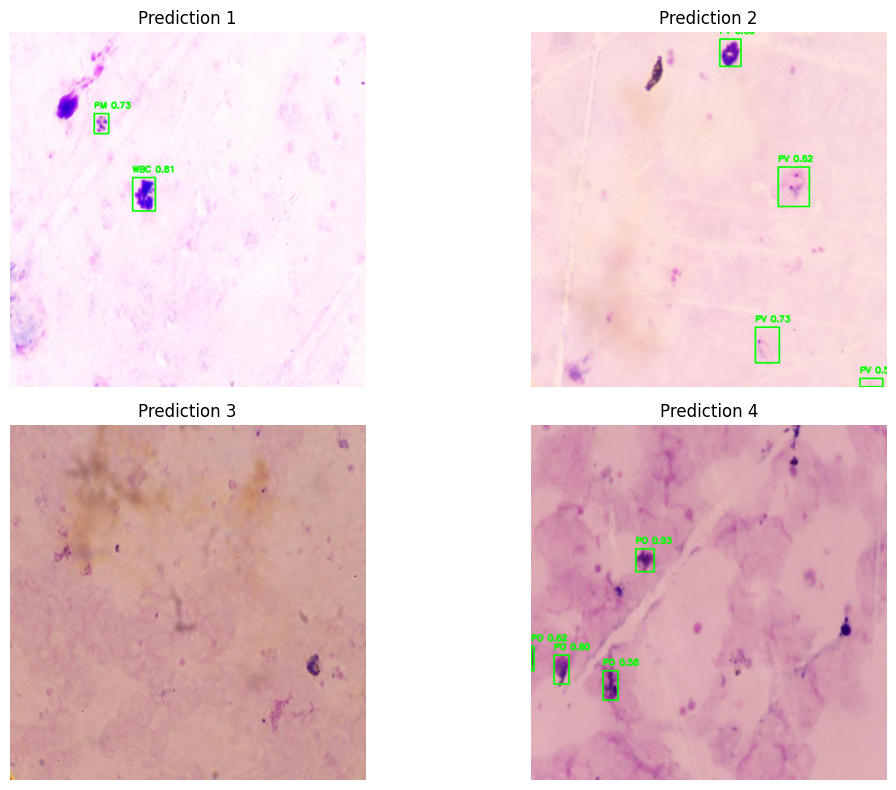

Model saved to /kaggle/working/malaria_yolov10.pt


In [12]:
plt.figure(figsize=(12, 8))
for i, img_path in enumerate(test_images):
    results = model.predict(img_path, conf=0.5, iou=0.5)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        class_id = int(box.cls[0]) if box.cls.ndim > 0 else int(box.cls)
        conf_score = float(box.conf[0]) if box.conf.ndim > 0 else float(box.conf)
        label = f"{results[0].names[class_id]} {conf_score:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Prediction {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Save model
model.save('/kaggle/working/malaria_yolov10.pt')
print("Model saved to /kaggle/working/malaria_yolov10.pt")
